# About Dataset

link https://www.kaggle.com/datasets/ahsan81/hotel-reservations-classification-dataset

Context
The online hotel reservation channels have dramatically changed booking possibilities and customers’ behavior. A significant number of hotel reservations are called-off due to cancellations or no-shows. The typical reasons for cancellations include change of plans, scheduling conflicts, etc. This is often made easier by the option to do so free of charge or preferably at a low cost which is beneficial to hotel guests but it is a less desirable and possibly revenue-diminishing factor for hotels to deal with.

## Imports

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
import kagglehub
import os
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    f1_score, classification_report, confusion_matrix
)
import pandas as pd
from sklearn.model_selection import train_test_split

## Load The Data

In [7]:
# Download latest version
path = kagglehub.dataset_download("ahsan81/hotel-reservations-classification-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'hotel-reservations-classification-dataset' dataset.
Path to dataset files: /kaggle/input/hotel-reservations-classification-dataset


In [9]:
print(os.listdir(path))

['Hotel Reservations.csv', '.nfs0000000056e404de0000001b']


In [10]:
df = pd.read_csv(os.path.join(path,'Hotel Reservations.csv'))

## Explore The Data

In [33]:
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,...,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Aviation,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,2,0,1,2,0,224,2017,10,2,0,...,0,0,0,0,0,0,0,0,1,0
1,2,0,2,3,0,5,2018,11,6,0,...,0,0,0,0,0,0,0,0,0,1
2,1,0,2,1,0,1,2018,2,28,0,...,0,0,0,0,0,0,0,0,0,1
3,2,0,0,2,0,211,2018,5,20,0,...,0,0,0,0,0,0,0,0,0,1
4,2,0,1,1,0,48,2018,4,11,0,...,0,0,0,0,0,0,0,0,0,1


In [13]:
df.isnull().sum().sum()

np.int64(0)

In [14]:
df.duplicated().sum()

np.int64(0)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 31 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          36275 non-null  int64  
 1   no_of_children                        36275 non-null  int64  
 2   no_of_weekend_nights                  36275 non-null  int64  
 3   no_of_week_nights                     36275 non-null  int64  
 4   required_car_parking_space            36275 non-null  int64  
 5   lead_time                             36275 non-null  int64  
 6   arrival_year                          36275 non-null  int64  
 7   arrival_month                         36275 non-null  int64  
 8   arrival_date                          36275 non-null  int64  
 9   repeated_guest                        36275 non-null  int64  
 10  no_of_previous_cancellations          36275 non-null  int64  
 11  no_of_previous_

In [27]:
df.shape


(36275, 18)

## Preprocessing

In [16]:
df['repeated_guest'].value_counts()

,count
repeated_guest,
0,35345
1,930


In [18]:
df = df.drop("Booking_ID",axis=1)

In [22]:
df['market_segment_type'].value_counts()

,count
market_segment_type,
Online,23214
Offline,10528
Corporate,2017
Complementary,391
Aviation,125


In [25]:
df['booking_status'].value_counts()

,count
booking_status,
1,24390
0,11885


In [24]:
df['booking_status'] = df['booking_status'].apply(lambda x: 1 if x == "Not_Canceled" else 0)

In [31]:
cat = ['type_of_meal_plan','room_type_reserved','market_segment_type']

dummy = pd.get_dummies(df[cat],drop_first= False).astype(int)

df = pd.concat([df,dummy],axis=1)

df = df.drop(cat,axis=1)

## Visualization

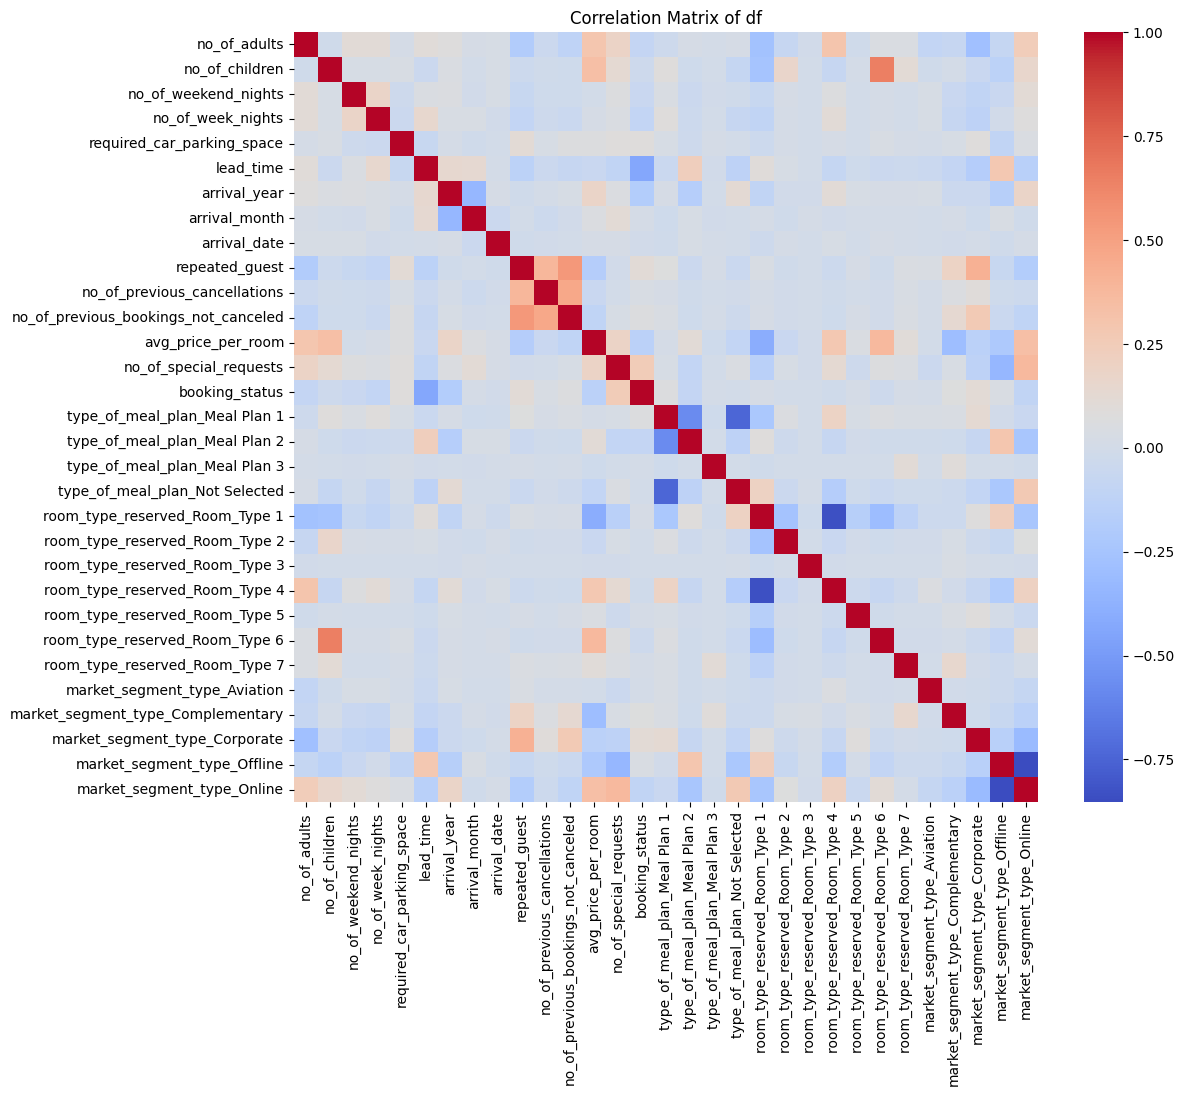

In [40]:
# Visualize correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Matrix of df')
plt.show()

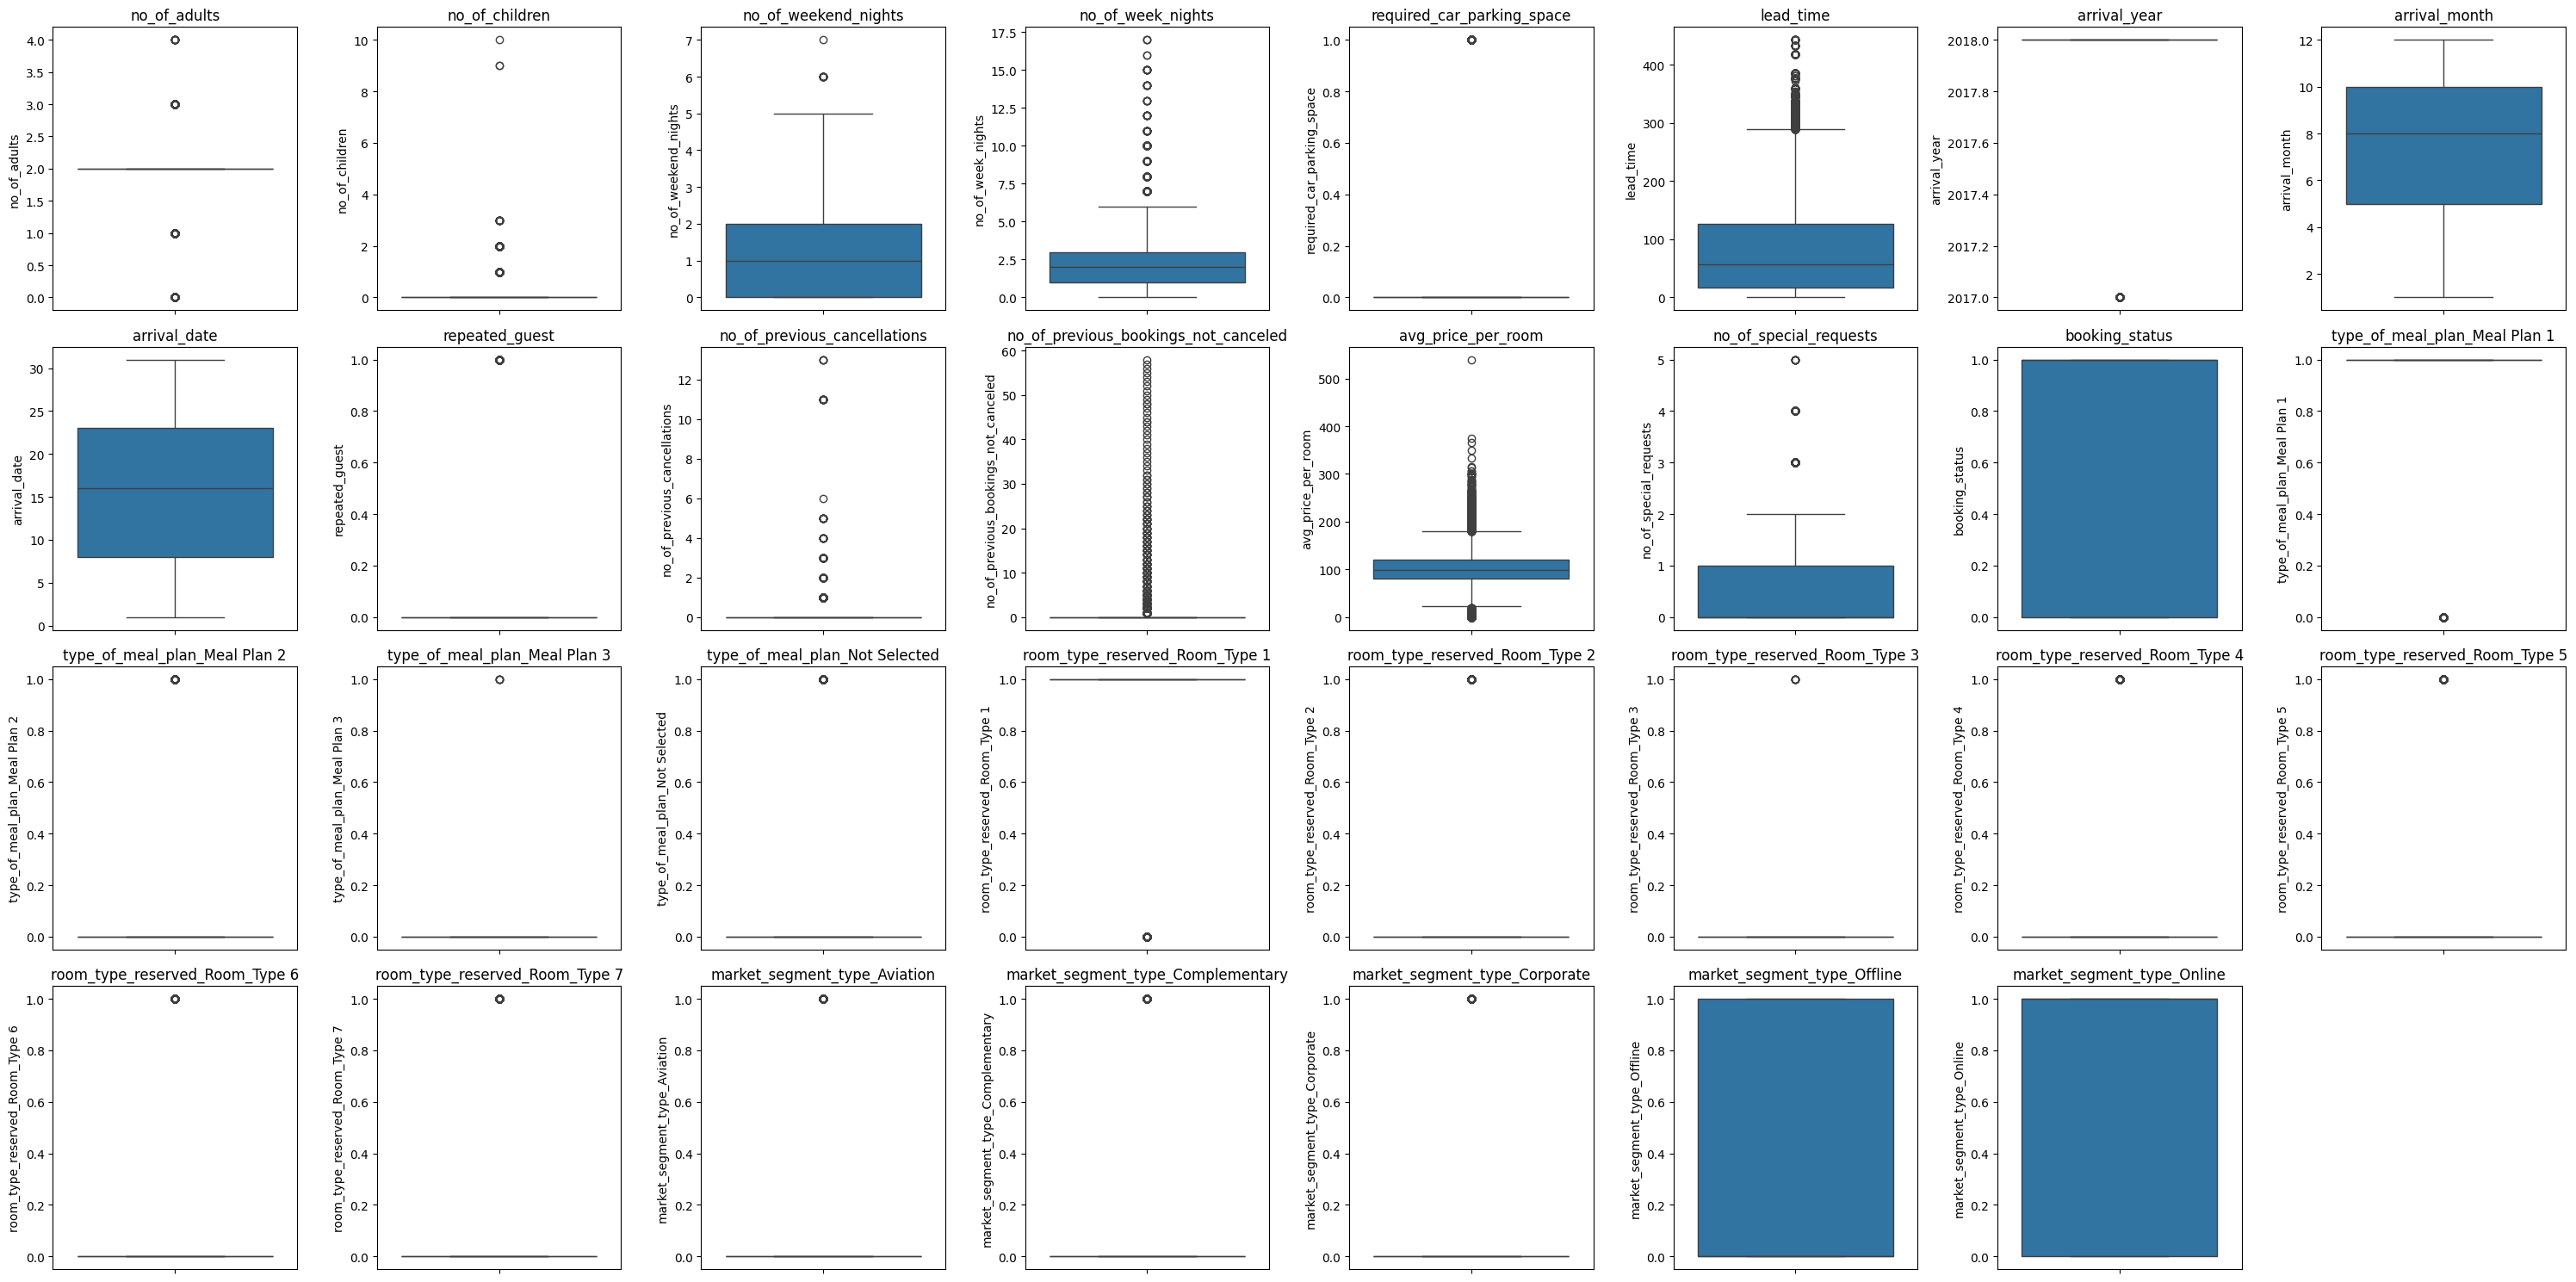

In [44]:
# Visualize outliers using box plots
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(30, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 8, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()


## Train Test Split

In [34]:
X = df.drop('booking_status',axis=1)
y = df['booking_status']

In [46]:
X_train, X_test, y_train, y_test = train_test_split(

                                                    X,y,
                                                    train_size=0.80,
                                                    random_state=42
)

##  Imbalance handling

In [48]:
pos = (y_train == 1).sum()
neg = len(y_train) - pos
scale_pos_weight = max(1.0, neg / max(1, pos))

In [57]:
xgb = XGBClassifier(
    tree_method="hist",
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=2,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="aucpr"
)

In [58]:
xgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False,
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=2, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=2000,
              n_jobs=None, num_parallel_tree=None, ...)

## Results

In [61]:
p = xgb.predict_proba(X_test)[:, 1]
roc = roc_auc_score(y_test, p)
ap  = average_precision_score(y_test, p)
print(f"ROC-AUC: {roc:.4f} | PR-AUC: {ap:.4f}")

# Threshold tuning for best F1 on the test set (quick check)
prec, rec, thr = precision_recall_curve(y_test, p)
f1s = 2 * prec * rec / (prec + rec + 1e-12)
best_idx = np.nanargmax(f1s)
best_thr = thr[max(0, best_idx - 1)] if best_idx < len(thr) else 0.5
print(f"Best F1: {f1s[best_idx]:.4f} at threshold {best_thr:.3f}")

y_pred = (p >= best_thr).astype(int)
print(classification_report(y_test, y_pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

ROC-AUC: 0.9612 | PR-AUC: 0.9800
Best F1: 0.9271 at threshold 0.409
              precision    recall  f1-score   support

           0     0.9003    0.7852    0.8388      2416
           1     0.8992    0.9566    0.9270      4839

    accuracy                         0.8995      7255
   macro avg     0.8998    0.8709    0.8829      7255
weighted avg     0.8996    0.8995    0.8976      7255

Confusion matrix:
 [[1897  519]
 [ 210 4629]]


## Neural Networks

### Imports

In [62]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Input
from keras.models import Sequential
from keras.metrics import AUC, Precision, Recall

In [68]:
from keras.layers import Dropout

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),  # Added dropout layer
    Dense(128, activation='relu'), # Increased hidden layers
    Dropout(0.3),  # Added dropout layer
    Dense(64, activation='relu'),
    Dropout(0.2), # Added dropout layer
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compile the model


In [69]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', AUC(), Precision(), Recall()])

## Train the model


In [70]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/30
454/454 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5789 - auc_1: 0.5148 - loss: 7.6983 - precision_1: 0.6782 - recall_1: 0.7075 - val_accuracy: 0.6670 - val_auc_1: 0.7565 - val_loss: 0.6332 - val_precision_1: 0.6670 - val_recall_1: 1.0000
Epoch 2/30
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6550 - auc_1: 0.5311 - loss: 0.6991 - precision_1: 0.6739 - recall_1: 0.9445 - val_accuracy: 0.6670 - val_auc_1: 0.7446 - val_loss: 0.6404 - val_precision_1: 0.6670 - val_recall_1: 1.0000
Epoch 3/30
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6637 - auc_1: 0.5513 - loss: 0.6517 - precision_1: 0.6698 - recall_1: 0.9818 - val_accuracy: 0.6670 - val_auc_1: 0.7719 - val_loss: 0.6261 - val_precision_1: 0.6670 - val_recall_1: 1.0000
Epoch 4/30
454/454 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6653 - auc_1: 0.6120 - loss: 0.6283 - precision_1: 0.6686 - recall_1: 0.9889 - val_accuracy: 0.6670 - val_auc_1: 0.7750 - val_loss: 0.5774 - val_precision_1: 0.6670 - val_r

## Evaluate the model

In [71]:
# Evaluate the model
loss, accuracy, auc, precision, recall = model.evaluate(X_test, y_test, verbose=0)

print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')
print(f'Test AUC: {auc:.4f}')
print(f'Test Precision: {precision:.4f}')
print(f'Test Recall: {recall:.4f}')

Test Loss: 0.4392
Test Accuracy: 0.8055
Test AUC: 0.8661
Test Precision: 0.8327
Test Recall: 0.8865


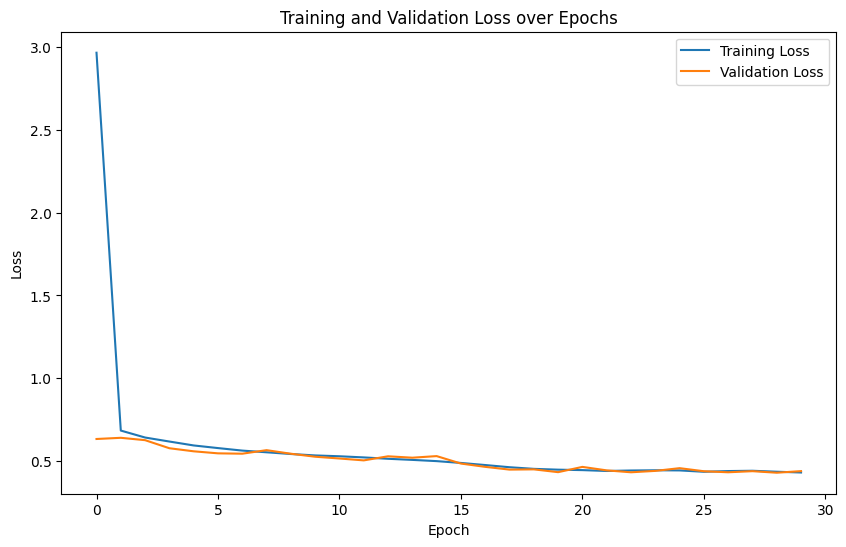

In [72]:
# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()